Cloning into 'GreenPulse'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 211 (delta 30), reused 33 (delta 15), pack-reused 153 (from 3)
Receiving objects: 100% (211/211), 194.94 MiB | 2.82 MiB/s, done.
Resolving deltas: 100% (76/76), done.
Updating files: 100% (47/47), done.
/content/GreenPulse
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Using Colab cache for faster access to the 'plant-disease-detection' dataset.
/kaggle/input/plantvillage-dataset
/kaggle/input/plant-disease-detection
Class mapping defined for 7 unified target classes
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Using Colab cache for faster access to the 'plant-disease-detection' dataset.
Using Colab cache for faster access to the 'cacao-diseases' dataset.
Cleaned dataset! Removed 5484 duplicate images.

Clean Unified Dataset Structure:
  └─ Tomato_Late_B

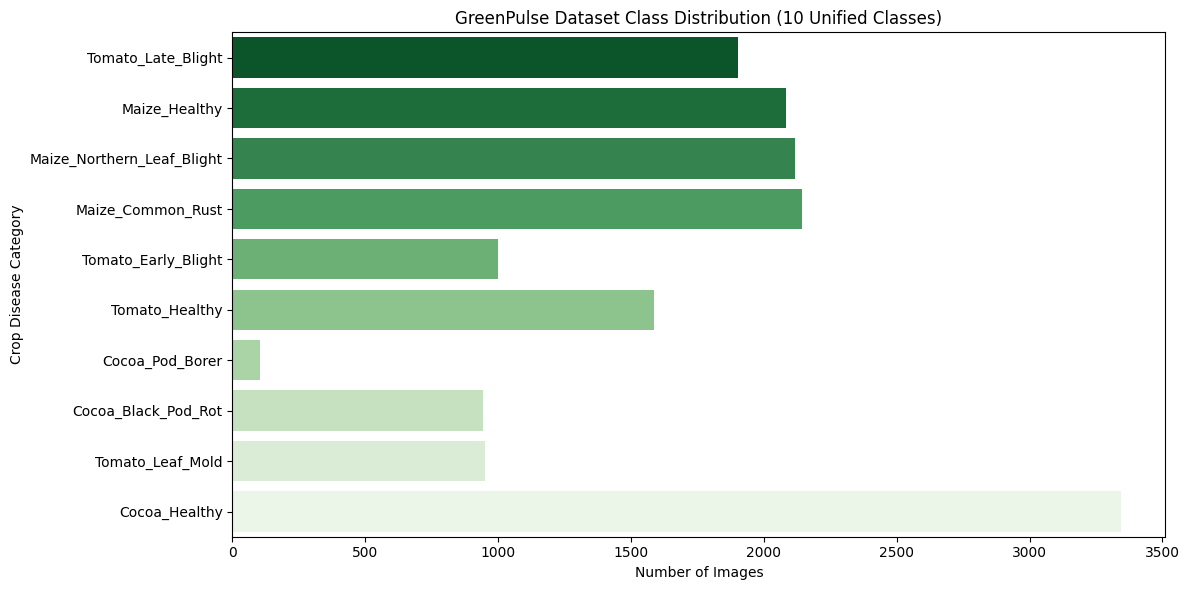

Cloning into 'GreenPulse'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 211 (delta 30), reused 33 (delta 15), pack-reused 153 (from 3)
Receiving objects: 100% (211/211), 194.94 MiB | 2.53 MiB/s, done.
Resolving deltas: 100% (76/76), done.
Updating files: 100% (47/47), done.
/content/GreenPulse/GreenPulse
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Using Colab cache for faster access to the 'plant-disease-detection' dataset.
/kaggle/input/plantvillage-dataset
/kaggle/input/plant-disease-detection
Class mapping defined for 7 unified target classes
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Using Colab cache for faster access to the 'plant-disease-detection' dataset.
Using Colab cache for faster access to the 'cacao-diseases' dataset.
Cleaned dataset! Removed 5484 duplicate images.

Clean Unified Dataset Structure:
  └─ To

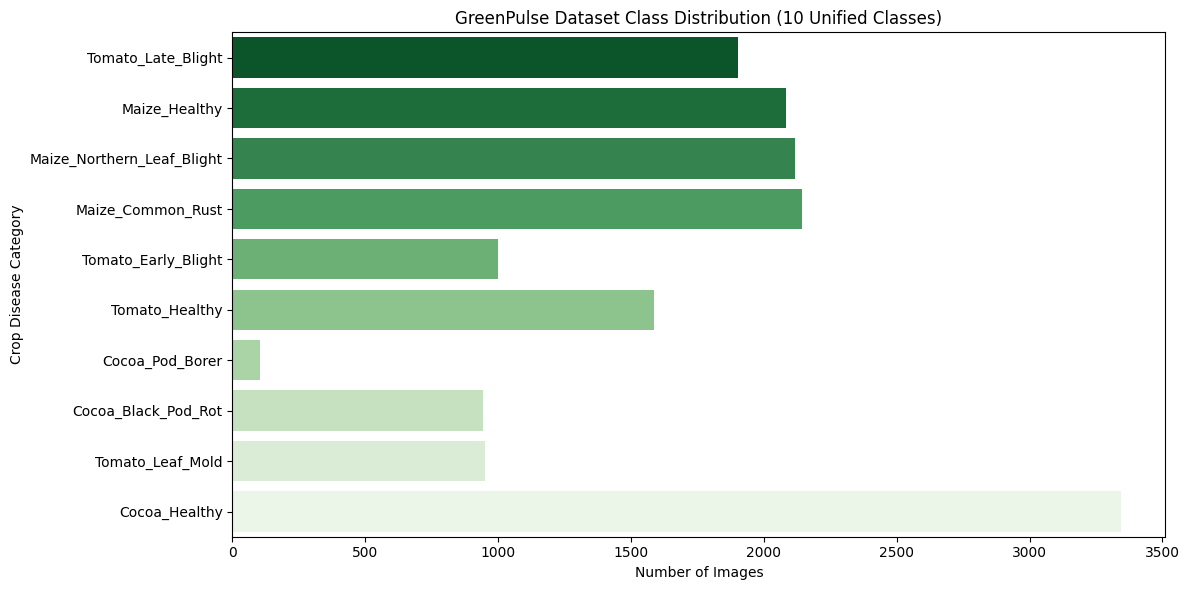

CUDA available: True
GPU: Tesla T4
True
Using device: cuda
GPU: Tesla T4
['Cocoa_Black_Pod_Rot', 'Cocoa_Healthy', 'Cocoa_Pod_Borer', 'Maize_Common_Rust', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold']
16172
Train: 11320
Validation: 2425
Test: 2427
Training images: 11320
Validation images: 2425
Test images: 2427
Training batches: 354
Validation batches: 76
Test batches: 76


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([32, 3, 224, 224])
torch.Size([32])
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 60.4MB/s]


Trainable parameters:
 classifier.0.weight
 classifier.0.bias
 classifier.3.weight
 classifier.3.bias
Epoch  1/5 | train loss 0.677 acc 0.837 | val loss 0.260 acc 0.924
Epoch  2/5 | train loss 0.231 acc 0.932 | val loss 0.182 acc 0.941
Epoch  3/5 | train loss 0.180 acc 0.941 | val loss 0.149 acc 0.952
Epoch  4/5 | train loss 0.148 acc 0.949 | val loss 0.152 acc 0.948
Epoch  5/5 | train loss 0.137 acc 0.954 | val loss 0.133 acc 0.957
{'train_loss': [0.6767034477774752, 0.231004315746336, 0.18027538331258422, 0.1481902335589429, 0.136960891752698], 'train_acc': [0.8374558303886925, 0.9318904593639576, 0.9414310954063604, 0.9493816254416961, 0.9543286219081272], 'val_loss': [0.25969671830688557, 0.18155626877067016, 0.14885423486380234, 0.15224480345461172, 0.1328505615897707], 'val_acc': [0.9237113402061856, 0.9414432989690722, 0.9521649484536082, 0.9484536082474226, 0.9567010309278351]}
True
Model size: 16.28 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!git clone https://github.com/KekeliIsHere/GreenPulse.git
%cd GreenPulse
%run notebooks/00_data_exploration_and_cleaning.ipynb
%run notebooks/01_model_training.ipynb

In [2]:
#Import required libraries
import torch
import numpy as np
import matplotlib.pyplot as plt

#Importing the evaluation metrics
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Use GPU if available, otherwise use CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device: ", device)

Using device:  cuda


In [3]:
import torch.nn as nn
from torchvision import models

#Loading the saved model weights
checkpoint = torch.load( "models/crop_disease_model.pth",map_location = device)

#Recreate the MobileNetV3 model
model = models.mobilenet_v3_large(weights=None)

#Modify the output layer for the 10 disease classes
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    10
)

#Load the trained weights
model.load_state_dict(checkpoint)

#Move model to the selected device
model = model.to(device)
#Set model to evaluation mode
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [4]:
#Store the actual and predicted class labels
all_labels = []
all_predictions = []

#Run predictions without calculating gradients
with torch.inference_mode():

    #Loop through the test dataset
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        #Get model predictions
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        #Store results for evaluation
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
#Check that all test images were evaluated
print("True labels:", len(all_labels))
print("Predictions:", len(all_predictions))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


True labels: 2427
Predictions: 2427


In [5]:
#Calculating overall test accuracy
accuracy = accuracy_score(all_labels, all_predictions)

#Calculating weighted precision
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

#Calculating weighted recall
recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

#Calculating weighted F1-score
f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

#Display evaluation results
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1 Score:      {f1:.4f}")

Test Accuracy: 96.25%
Precision:     0.9614
Recall:        0.9625
F1 Score:      0.9614


In [6]:
from sklearn.metrics import classification_report

#Define the disease class names in the correct order
class_names = [
    'Cocoa_Black_Pod_Rot',
    'Cocoa_Healthy',
    'Cocoa_Pod_Borer',
    'Maize_Common_Rust',
    'Maize_Healthy',
    'Maize_Northern_Leaf_Blight',
    'Tomato_Early_Blight',
    'Tomato_Healthy',
    'Tomato_Late_Blight',
    'Tomato_Leaf_Mold'
]

#Display performance metrics for each disease class
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )
)

                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot       0.80      0.67      0.73       144
             Cocoa_Healthy       0.91      0.96      0.94       509
           Cocoa_Pod_Borer       0.62      0.53      0.57        15
         Maize_Common_Rust       1.00      1.00      1.00       320
             Maize_Healthy       1.00      1.00      1.00       301
Maize_Northern_Leaf_Blight       1.00      1.00      1.00       298
       Tomato_Early_Blight       0.98      0.94      0.96       143
            Tomato_Healthy       1.00      1.00      1.00       241
        Tomato_Late_Blight       0.99      0.98      0.98       282
          Tomato_Leaf_Mold       0.95      1.00      0.97       174

                  accuracy                           0.96      2427
                 macro avg       0.92      0.91      0.92      2427
              weighted avg       0.96      0.96      0.96      2427



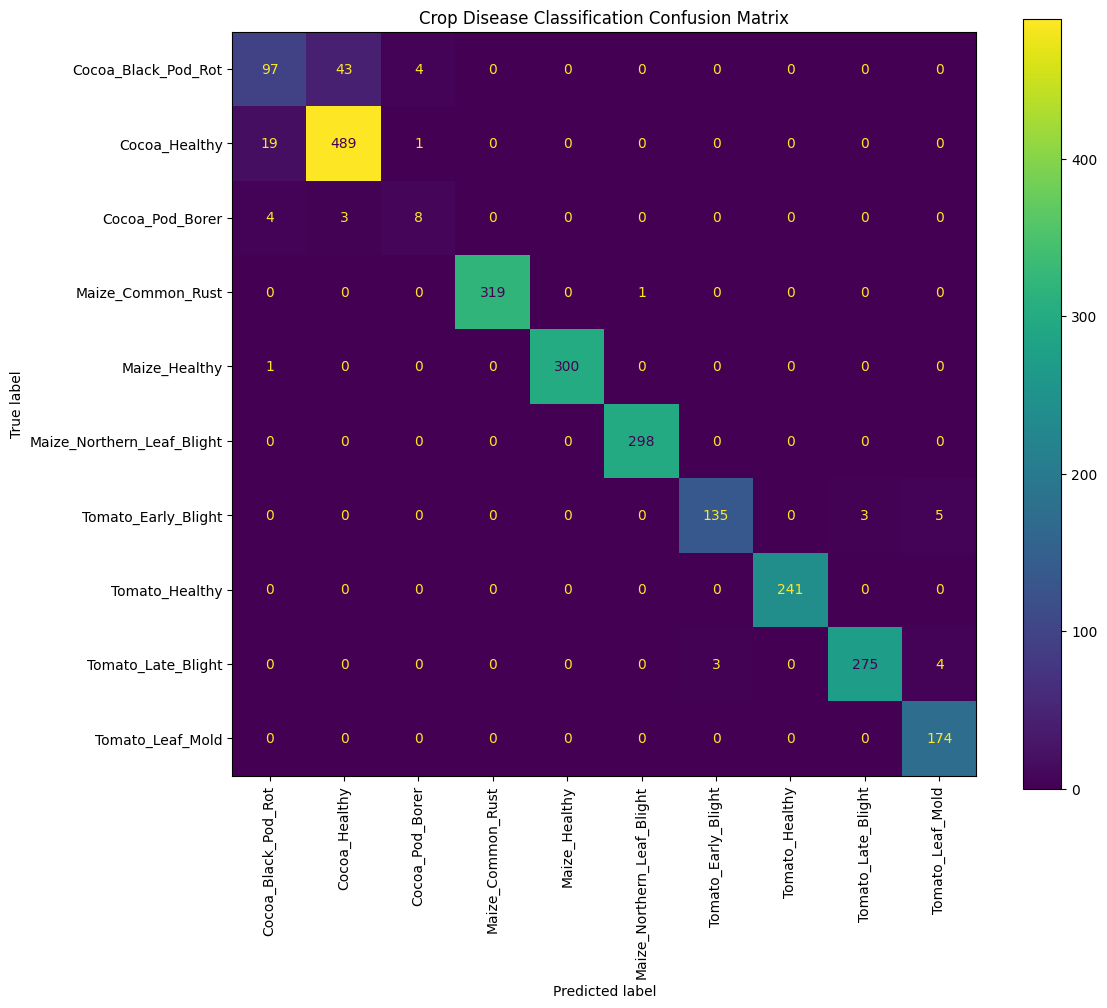

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

#Calculating the confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

#Create the figure
fig, ax = plt.subplots(figsize=(12, 10))

#Display the confusion matrix with class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

#Plot and rotate labels for readability
disp.plot(
    ax=ax,
    xticks_rotation=90
)

#Adding title and display
plt.title("Crop Disease Classification Confusion Matrix")
plt.show()

##Confusion Matrix Analysis
The confusion matrix shows that the MobileNetV3 model performs particularly well on the maize and tomato classes. Maize Northern Leaf Blight and Tomato Healthy were classified correctly for all test samples, while very few errors occurred among the other maize classes. Of the 144 Cocoa Black Pod Rot images, 43 images were incorrectly classified as Cocoa Healthy. Cocoa Pod Borer was also challenging, with only 8 of 15 test samples correctly identified. This may partly result from class imbalance because Cocoa Pod Borer has substantially fewer samples than the other disease categories.These results indicate that improving the model's performance on underrepresented cocoa diseases should be a focus of further tuning.  

##Training and Validation Performance Analysis

In [8]:
#Storing the training and validation results for each epoch
history = {
    "train_loss": [
        0.6815555452879242,
        0.2312959857521967,
        0.17782312015551982,
        0.14987477635958169,
        0.13809144177306246
    ],

    "train_acc": [
        0.8360424028268552,
        0.9326855123674912,
        0.9412544169611308,
        0.9507950530035336,
        0.9539752650176678
    ],

    "val_loss": [
        0.2667954191104653,
        0.1829991599948136,
        0.15479528693501482,
        0.15019116851318742,
        0.13896452529605516
    ],

    "val_acc": [
        0.9204123711340206,
        0.9385567010309278,
        0.9488659793814433,
        0.9472164948453609,
        0.9554639175257732
    ]
}

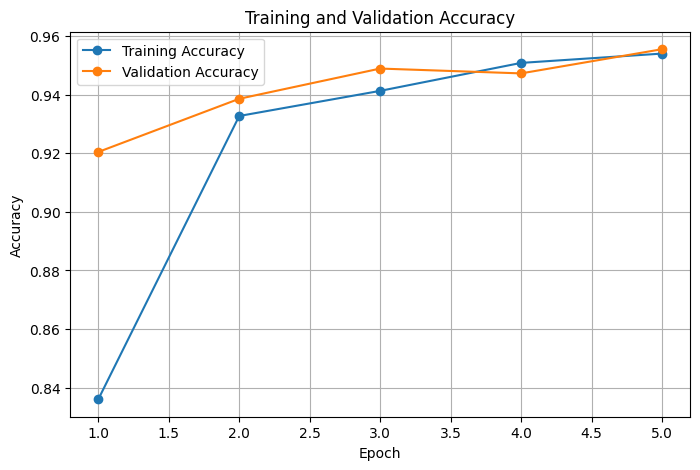

In [9]:
#Creating epoch numbers for the x-axis
epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))

#Plot training accuracy
plt.plot(
    epochs,
    history["train_acc"],
    marker="o",
    label="Training Accuracy"
)
#Plot validation accuracy
plt.plot(
    epochs,
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

#Label and display the graph
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

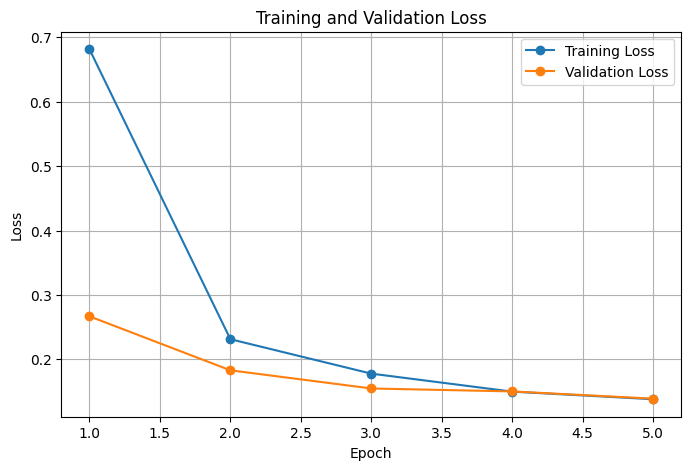

In [10]:
# Create epoch numbers for the x-axis
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

# Plot training loss
plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

# Plot validation loss
plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

# Label and display the graph
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

**Training Analysis:**
Both training and validation performance improved steadily across the five epochs.
Training accuracy increased from approximately 83.6% to 95.4%, while validation accuracy increased from approximately 92.0% to 95.5%. At the same time, both training and validation loss decreased. The relatively small difference between training and validation performance suggests that the model did not show significant overfitting during training. The final validation accuracy was also consistent with the 96% accuracy obtained on the test set.

In [11]:
from collections import Counter

# Get the class labels from the training dataset
train_targets = [
    train_ds.dataset.targets[i]
    for i in train_ds.indices
]

#Count the number of training imaged in eahc class
class_counts = Counter(train_targets)

#Display the number of images for each disease class
for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: {class_counts[i]}"
    )

Cocoa_Black_Pod_Rot: 644
Cocoa_Healthy: 2318
Cocoa_Pod_Borer: 70
Maize_Common_Rust: 1514
Maize_Healthy: 1457
Maize_Northern_Leaf_Blight: 1501
Tomato_Early_Blight: 722
Tomato_Healthy: 1110
Tomato_Late_Blight: 1331
Tomato_Leaf_Mold: 653


In [12]:
# Convert class counts into a tensor
counts = torch.tensor(
    [
        class_counts[i]
        for i in range(len(class_names))
    ],
    dtype=torch.float
)

# Calculate class weights to account for class imbalance
class_weights = counts.sum() / (
    len(counts) * counts
)

# Display the calculated weights
print(class_weights)

tensor([ 1.7578,  0.4884, 16.1714,  0.7477,  0.7769,  0.7542,  1.5679,  1.0198,
         0.8505,  1.7335])


In [13]:
#Set the number of output classes
num_classes = len(class_names)

# Load pretrained MobileNetV3 weights
weights = models.MobileNet_V3_Large_Weights.DEFAULT

# Create the pretrained MobileNetV3 model
weighted_model = models.mobilenet_v3_large(
    weights=weights
)

# Freeze the pretrained layers
for param in weighted_model.parameters():
    param.requires_grad = False

# Replace the final layer for our 10 disease classes
weighted_model.classifier[3] = nn.Linear(
    weighted_model.classifier[3].in_features,
    num_classes
)

# Allow the classifier layers to be trained
for param in weighted_model.classifier.parameters():
    param.requires_grad = True

# Move the model to the selected device
weighted_model = weighted_model.to(device)

# Display the parameters that will be trained
print("Trainable parameters:")

for name, param in weighted_model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable parameters:
classifier.0.weight
classifier.0.bias
classifier.3.weight
classifier.3.bias


In [14]:
# Use weighted loss to give more importance to underrepresented classes
weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

# Optimize only the trainable parameters
weighted_optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        weighted_model.parameters()
    ),
    lr=1e-4
)

# Train for 5 epochs
num_epochs = 5

# Store training and validation performance
weighted_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):


    # TRAINING

    weighted_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        weighted_optimizer.zero_grad()
        # Make predictions
        outputs = weighted_model(images)
        #Calculate weighted loss
        loss = weighted_criterion(
            outputs,
            labels
        )

        #Update the model
        loss.backward()
        weighted_optimizer.step()

        #Track training loss
        train_loss += loss.item() * images.size(0)

        #Get predicted classes
        _, predictions = torch.max(
            outputs,
            1
        )

        #Count correct preditions
        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)


    # Calculate average training loss and accuracy
    train_loss /= train_total
    train_accuracy = (
        train_correct / train_total
    )



    # VALIDATION
    weighted_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Validate without updating model weights
    with torch.inference_mode():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = weighted_model(images)

            loss = weighted_criterion(
                outputs,
                labels
            )

            # Track validation loss
            val_loss += (
                loss.item() * images.size(0)
            )

            _, predictions = torch.max(
                outputs,
                1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    # Calculate average validation loss and accuracy
    val_loss /= val_total
    val_accuracy = (
        val_correct / val_total
    )

    # Save results for each epoch
    weighted_history["train_loss"].append(
        train_loss
    )
    weighted_history["train_acc"].append(
        train_accuracy
    )
    weighted_history["val_loss"].append(
        val_loss
    )
    weighted_history["val_acc"].append(
        val_accuracy
    )


    # Display progress
    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"train loss {train_loss:.3f} "
        f"acc {train_accuracy:.3f} | "
        f"val loss {val_loss:.3f} "
        f"acc {val_accuracy:.3f}"
    )


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch  1/5 | train loss 0.861 acc 0.827 | val loss 0.367 acc 0.920
Epoch  2/5 | train loss 0.326 acc 0.911 | val loss 0.238 acc 0.932
Epoch  3/5 | train loss 0.246 acc 0.922 | val loss 0.225 acc 0.940
Epoch  4/5 | train loss 0.206 acc 0.934 | val loss 0.202 acc 0.932
Epoch  5/5 | train loss 0.190 acc 0.937 | val loss 0.188 acc 0.935


In [15]:
# Store the actual and predicted validation labels
val_labels = []
val_predictions = []

# Set the weighted model to evaluation mode
weighted_model.eval()

# Make predictions without calculating gradients
with torch.inference_mode():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Get model outputs
        outputs = weighted_model(images)

        # Select the class with the highest score
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        #Store actual and predicted labels
        val_labels.extend(
            labels.cpu().numpy()
        )

        val_predictions.extend(
            predictions.cpu().numpy()
        )

In [16]:
# Calculate validation accuracy
weighted_val_accuracy = accuracy_score(
    val_labels,
    val_predictions
)

# Calculate macro F1-score
weighted_macro_f1 = f1_score(
    val_labels,
    val_predictions,
    average="macro",
    zero_division=0
)

# Calculate weighted F1-score
weighted_f1 = f1_score(
    val_labels,
    val_predictions,
    average="weighted",
    zero_division=0
)

# Display overall evaluation results
print(f"Validation Accuracy: {weighted_val_accuracy:.4f}")
print(f"Macro F1:            {weighted_macro_f1:.4f}")
print(f"Weighted F1:         {weighted_f1:.4f}")

# Display performance for each disease class
print(
    classification_report(
        val_labels,
        val_predictions,
        target_names=class_names,
        zero_division=0
    )
)

Validation Accuracy: 0.9348
Macro F1:            0.8938
Weighted F1:         0.9375
                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot       0.66      0.80      0.72       155
             Cocoa_Healthy       0.95      0.85      0.90       517
           Cocoa_Pod_Borer       0.43      0.89      0.58        18
         Maize_Common_Rust       0.99      0.99      0.99       310
             Maize_Healthy       1.00      1.00      1.00       326
Maize_Northern_Leaf_Blight       0.99      0.98      0.99       317
       Tomato_Early_Blight       0.89      0.92      0.90       135
            Tomato_Healthy       0.99      1.00      1.00       234
        Tomato_Late_Blight       0.99      0.91      0.95       288
          Tomato_Leaf_Mold       0.87      0.98      0.92       125

                  accuracy                           0.93      2425
                 macro avg       0.87      0.93      0.89      2425
              weighted avg    

In [17]:
# Store baseline model validation results
baseline_val_labels = []
baseline_val_predictions = []

# Set the baseline model to evaluation mode
model.eval()

# Make predictions without calculating gradients
with torch.inference_mode():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Get model outputs
        outputs = model(images)

        # Select the class with the highest score
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        # Store actual and predicted labels
        baseline_val_labels.extend(
            labels.cpu().numpy()
        )

        baseline_val_predictions.extend(
            predictions.cpu().numpy()
        )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [18]:
# Calculate baseline validation accuracy
baseline_val_accuracy = accuracy_score(
    baseline_val_labels,
    baseline_val_predictions
)

# Calculate baseline macro F1-score
baseline_macro_f1 = f1_score(
    baseline_val_labels,
    baseline_val_predictions,
    average="macro",
    zero_division=0
)

# Calculate baseline weighted F1-score
baseline_weighted_f1 = f1_score(
    baseline_val_labels,
    baseline_val_predictions,
    average="weighted",
    zero_division=0
)

# Display overall baseline results
print(
    f"Baseline Validation Accuracy: "
    f"{baseline_val_accuracy:.4f}"
)

print(
    f"Baseline Macro F1: "
    f"{baseline_macro_f1:.4f}"
)

print(
    f"Baseline Weighted F1: "
    f"{baseline_weighted_f1:.4f}"
)

#Display performance for each disease class
print(
    classification_report(
        baseline_val_labels,
        baseline_val_predictions,
        target_names=class_names,
        zero_division=0
    )
)

Baseline Validation Accuracy: 0.9592
Baseline Macro F1: 0.9214
Baseline Weighted F1: 0.9582
                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot       0.87      0.70      0.78       155
             Cocoa_Healthy       0.92      0.97      0.94       517
           Cocoa_Pod_Borer       0.67      0.67      0.67        18
         Maize_Common_Rust       1.00      0.99      0.99       310
             Maize_Healthy       1.00      1.00      1.00       326
Maize_Northern_Leaf_Blight       0.99      0.99      0.99       317
       Tomato_Early_Blight       0.95      0.93      0.94       135
            Tomato_Healthy       0.99      1.00      1.00       234
        Tomato_Late_Blight       0.99      0.95      0.97       288
          Tomato_Leaf_Mold       0.90      0.99      0.94       125

                  accuracy                           0.96      2425
                 macro avg       0.93      0.92      0.92      2425
              weighted

##Full Class Wighting Analysis

A class-weighted loss function was tested to address the imbalance observed in the cocoa disease classes. Although weighting increased the recall of minority classes such as Cocoa Pod Borer from 0.67 to 0.89, its precision decreased from 0.67 to 0.43. Consequently, the Cocoa Pod Borer F1-score decreased from 0.67 to 0.58. Overall validation accuracy also decreased from 95.96% for the baseline model to 92.21% for the weighted model. The baseline MobileNetV3 model therefore provided a better balance between overall and per-class performance.

In [19]:
#Creating milder class weights to reduce the effect of strong weighting
mild_weights = torch.sqrt(class_weights)

#Display the new class weights
print(mild_weights)

tensor([1.3258, 0.6988, 4.0214, 0.8647, 0.8814, 0.8684, 1.2521, 1.0099, 0.9222,
        1.3166])


In [20]:
#Set the numner of disease classes
num_classes = len(class_names)

#Load pretrained MobileNetV3 weights
weights = models.MobileNet_V3_Large_Weights.DEFAULT

#Create  anew MobileNetV3 model for mild weighting
mild_model = models.mobilenet_v3_large(
    weights=weights
)

# Freeze all pretrained parameters
for param in mild_model.parameters():
    param.requires_grad = False

# Replace the final layer for the 10 disease classes
mild_model.classifier[3] = nn.Linear(
    mild_model.classifier[3].in_features,
    num_classes
)

# Make classifier trainable
for param in mild_model.classifier.parameters():
    param.requires_grad = True

#Move the model to the selected device
mild_model = mild_model.to(device)

In [21]:
#Defining the loss function using the milder class weights
mild_criterion = nn.CrossEntropyLoss(
    weight=mild_weights.to(device)
)

In [22]:
#Creating an Adam optimiser for the trainable classifier parameters
mild_optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        mild_model.parameters()
    ),
    lr=1e-4
)

In [ ]:
#Train the mild-weighted model for 5 epochs
num_epochs = 5

#Store training and validation results
mild_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):

    #TRAINING
    mild_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        #Clearing previous gradients
        mild_optimizer.zero_grad()

        #Making predictions and calculating loss
        outputs = mild_model(images)

        loss = mild_criterion(
            outputs,
            labels
        )

        #Updating the model parameters
        loss.backward()
        mild_optimizer.step()

        #Tracking the training loss
        train_loss += (
            loss.item() * images.size(0)
        )

        # Getting predicted classes
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        #Count correct predictions
        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    #Calculate training loss and accuracy
    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # Validation
    mild_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    #Validate without updating model parameters
    with torch.inference_mode():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = mild_model(images)

            loss = mild_criterion(
                outputs,
                labels
            )

            #Track validation loss
            val_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            #Count correct predictions
            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    #Calculate the validation loss and accuracy
    val_loss /= val_total
    val_accuracy = val_correct / val_total

    #Save results for each epoch
    mild_history["train_loss"].append(train_loss)
    mild_history["train_acc"].append(train_accuracy)
    mild_history["val_loss"].append(val_loss)
    mild_history["val_acc"].append(val_accuracy)

    #Display progress
    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"train loss {train_loss:.3f} "
        f"acc {train_accuracy:.3f} | "
        f"val loss {val_loss:.3f} "
        f"acc {val_accuracy:.3f}"
    )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch  1/5 | train loss 0.756 acc 0.850 | val loss 0.309 acc 0.932
Epoch  2/5 | train loss 0.269 acc 0.929 | val loss 0.216 acc 0.942


In [ ]:
#Store the actual and predicted validation labe;s
mild_val_labels = []
mild_val_predictions = []

#Set the mild-weighted model to evaluation mode
mild_model.eval()

#Make predictions without calculating gradients
with torch.inference_mode():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        #Get model outputs
        outputs = mild_model(images)

        #select the class which has the highest score
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        #Store actual and predicted labels
        mild_val_labels.extend(
            labels.cpu().numpy()
        )

        mild_val_predictions.extend(
            predictions.cpu().numpy()
        )

In [ ]:
# Calculate validation accuracy
mild_val_accuracy = accuracy_score(
    mild_val_labels,
    mild_val_predictions
)

# Calculate macro F1-score
mild_macro_f1 = f1_score(
    mild_val_labels,
    mild_val_predictions,
    average="macro",
    zero_division=0
)

# Calculate weighted F1-score
mild_weighted_f1 = f1_score(
    mild_val_labels,
    mild_val_predictions,
    average="weighted",
    zero_division=0
)


# Display overall evaluation results
print(f"Validation Accuracy: {mild_val_accuracy:.4f}")
print(f"Macro F1:            {mild_macro_f1:.4f}")
print(f"Weighted F1:         {mild_weighted_f1:.4f}")

# Display performance for each disease class
print(
    classification_report(
        mild_val_labels,
        mild_val_predictions,
        target_names=class_names,
        zero_division=0
    )
)

##HyperParameter Tuning Results

Hyperparameter Tuning and Model Comparison:
Class weighting was investigated as a method of addressing the imbalance in the training dataset, particularly for the Cocoa Pod Borer class. The first experiment used inverse-frequency class weights. Although this increased recall for the minority cocoa classes, it reduced precision and lowered overall validation accuracy to 92.21%. A second experiment used milder class weights obtained from the square root of the original weights. This improved validation accuracy to 93.90% and increased the Cocoa Pod Borer F1-score from 0.67 in the baseline model to 0.73. However, the baseline model still achieved the highest overall validation accuracy (95.96%), macro F1-score (0.9221), and weighted F1-score (0.9586). Therefore, the original MobileNetV3 model was retained as the final model because it provided the best overall balance across the disease classes.

In [ ]:
import pandas as pd

#Create a table ti compare the three model versions
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Full Class Weights",
        "Mild Class Weights"
    ],
    "Validation Accuracy": [
        0.9596,
        0.9221,
        0.9390
    ],
    "Macro F1": [
        0.9221,
        0.8877,
        0.9101
    ],
    "Weighted F1": [
        0.9586,
        0.9266,
        0.9410
    ],
    "Cocoa Pod Borer F1": [
        0.67,
        0.58,
        0.73
    ]
})

#Display the model comparison table
comparison

In [ ]:
#Select the metrics to compare
metrics = [
    "Validation Accuracy",
    "Macro F1",
    "Weighted F1"
]

#Plot the performance of each model
comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(9, 5)
)

#Label and display the graph
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")

plt.show()

## Final Evaluation Conclusion

The baseline MobileNetV3 model was selected as the final model after
evaluation and model comparison. It achieved a test accuracy of 96.00%,
with a weighted precision of 0.9587, recall of 0.9600, and F1-score of
0.9589.

The model performed particularly well on the maize and tomato disease
classes but showed weaker performance on some cocoa disease classes.
Class weighting was investigated to address this imbalance. Although
mild weighting improved the Cocoa Pod Borer F1-score, both weighted
models produced lower overall validation performance than the baseline.

Therefore, the baseline model was retained because it provided the best
overall balance across the disease classes. Future work could focus on
collecting more cocoa disease images and applying targeted augmentation
to improve performance on underrepresented classes.